In [38]:
import pandas as pd
import matplotlib.pyplot as plt


In [39]:
df = pd.read_csv("results/microbenchmark.csv",index_col=0)
df

,n_unique_words,dataset_length,chunktimer_0,fit_map,fit_reduce,fit_sorting,fit_total,rust_python_function_total,python_total,chunktimer_1,...,chunktimer_10_rel,chunktimer_14_rel,chunktimer_15_rel,chunktimer_18_rel,chunktimer_22_rel,chunktimer_20_rel,chunktimer_11_rel,python_overhead,rust_python_function_overhead,python_overhead_rel
3,100,1000000,47.752111,101.813460,34.770542,4.357381,140.941383,148.745498,233.981445,99.997179,...,0.660,0.678,0.683,0.690,0.702,0.684,0.718,93.040062,0.364,0.398
7,1000,1000000,43.706316,115.087296,40.727024,4.123042,159.937362,200.129335,248.913951,70.995938,...,0.621,0.430,0.408,0.682,0.592,0.549,0.602,88.976589,0.196,0.357
11,10000,1000000,50.759420,116.438794,57.051340,7.815083,181.305217,228.849559,271.028623,113.504144,...,0.404,0.566,0.287,0.590,0.637,0.556,0.516,89.723406,0.156,0.331
2,100,100000,9.554631,13.389404,4.295998,0.308867,17.994269,21.098783,25.161519,6.012430,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.167250,0.161,0.285
10,10000,100000,10.080222,15.525865,5.688384,0.747040,21.961289,25.017685,29.518815,9.860016,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.557526,0.152,0.256
6,1000,100000,6.220014,21.428262,5.662444,0.333257,27.423963,30.248568,34.141999,11.145035,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.718036,0.114,0.197
9,10000,10000,6.124380,6.135163,0.640009,0.538584,7.313756,8.031275,9.137987,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.824231,0.121,0.200
1,100,10000,5.667700,5.675181,0.055185,0.021326,5.751692,6.435474,6.910205,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.158513,0.069,0.168
5,1000,10000,6.120085,6.126209,0.117469,0.062997,6.306675,6.995535,7.556309,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.249634,0.074,0.165
0,100,1000,0.668996,0.674893,0.011180,0.005380,0.691453,1.269821,1.424945,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.733492,0.109,0.515


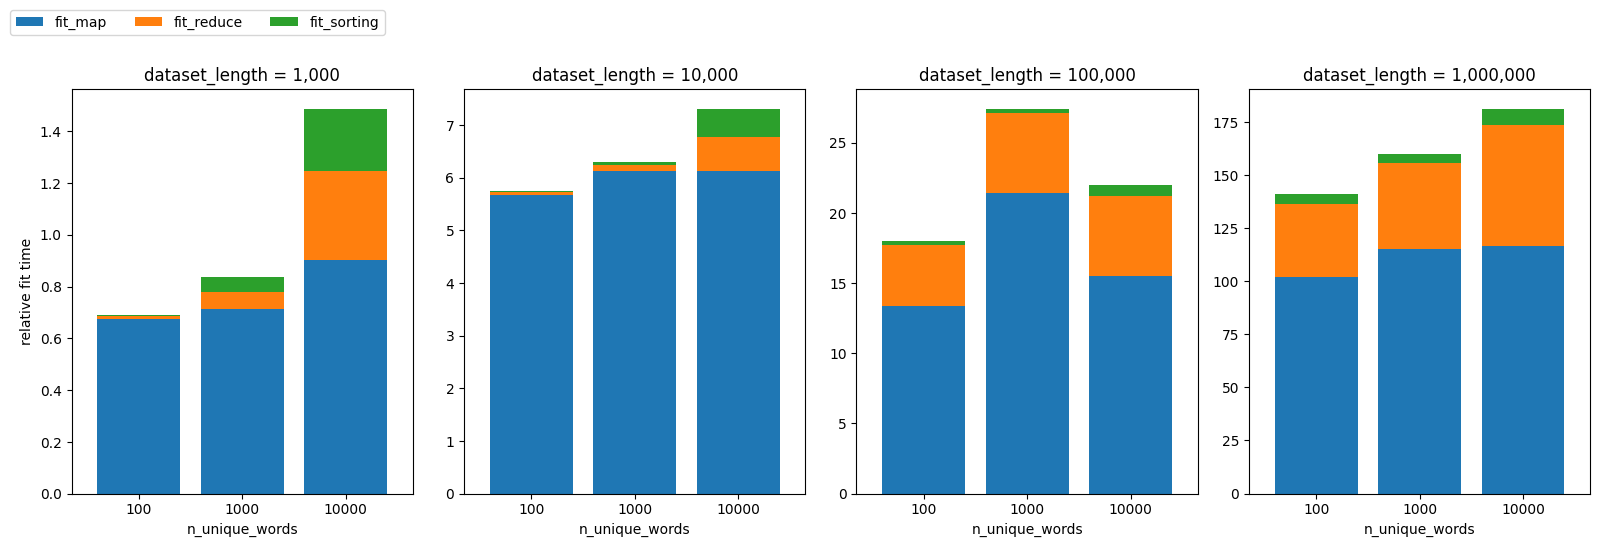

In [41]:
fit_cols = [ x for x in df.columns if x.startswith("fit_") and not x.endswith("_rel") and "total" not in x]

lengths = sorted(df["dataset_length"].unique(), reverse=False)

fig, axes = plt.subplots(1, len(lengths), figsize=(4 * len(lengths), 5))

for ax, length in zip(axes, lengths):
    sub = df[df["dataset_length"] == length].set_index("n_unique_words")
    sub = sub.sort_index()
    sub[fit_cols].plot.bar(stacked=True, ax=ax, legend=False, width=0.8)
    ax.set_title(f"dataset_length = {length:,}")
    ax.set_xlabel("n_unique_words")
    ax.tick_params(axis="x", rotation=0)

axes[0].set_ylabel("relative fit time")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center", ncol=len(fit_cols), bbox_to_anchor=(0.12, 1.02)
)

fig.tight_layout()
plt.show()
